# Decision: Normal Offset Strategy

**Status:** Resolved — **0.5 Å outward offset along vertex normals, PQR mesh only**
**Decision made:** See `THESISPROCESSES.md`

## Problem
SES mesh vertices sit exactly on the solvent-excluded surface boundary. This boundary can coincide with
a voxel edge or numerical discontinuity in the APBS `.dx` grid, producing spurious spike values.
Offsetting outward moves the sample point into the solvent-accessible region where the ESP field
is physically meaningful for molecular interactions — but too large an offset smooths over real
surface features and moves away from the protein.

## Options
- **0.0 Å** — sample at the surface exactly; most geometrically accurate but potentially hitting discontinuities
- **Small offset (0.1–0.5 Å)** — clears the SES boundary; minimal smoothing
- **Larger offset (1.0 Å)** — safely in solvent; may lose surface detail

## Approach
Sweep offsets `[0.0, 0.1, 0.25, 0.5, 1.0]` Å on both PDB and PQR meshes for `AF-Q16613-F1`.
Sampling method held fixed at **trilinear interpolation** to isolate the offset variable.

---

## Conclusion

**Decision: 0.5 Å offset, PQR mesh only.**

The sweep revealed a clear trade-off: smaller offsets preserve surface fidelity but retain singularity-driven spikes, while larger offsets over-smooth the field. 0.5 Å is the sweet spot where spike suppression is substantial and surface detail is still retained.

**Key findings:**
- At 0.0 Å (exact surface), the PDB mesh exhibits extreme spikes (std=13.3, max=130.5 kT/e) caused by near-surface hydrogen atoms not being represented in the structure. The PQR mesh is significantly better (std=6.9) due to explicit hydrogen placement, but still shows singularities.
- At 0.5 Å, PQR std drops to 2.6 and the range narrows to [−10.3, 17.8] kT/e — physically reasonable values for a protein surface in aqueous solution. The outlier fraction falls from 1.0% to 0.8%.
- At 1.0 Å, the std decreases only marginally further (2.3 vs 2.6) but Pearson r vs. the surface drops to 0.67, meaning meaningful spatial structure is being lost to over-smoothing.
- The PDB mesh is discarded entirely: even at 0.5 Å it retains std=4.2 and a wider range, reflecting the structural inaccuracy of sampling without explicit hydrogens.

**Decision recorded in:** `THESISPROCESSES.md`

In [58]:
# ── Display setup ─────────────────────────────────────────────────────────────
import os
os.environ.setdefault("DISPLAY", ":0")
os.environ.setdefault("WAYLAND_DISPLAY", "wayland-0")
os.environ.setdefault("XDG_RUNTIME_DIR", "/mnt/wslg/runtime-dir")

'/run/user/1000/'

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
import pyvista as pv
from IPython.display import display as ipy_display, Image as ipy_Image

# Off-screen rendering — displays inline in the notebook.
# To rotate interactively, run the "Interactive terminal" cell at the bottom.
pv.set_jupyter_backend("static")

PROJECT_ROOT = Path("../").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_config
from src.utils.paths import ProteinPaths
from src.surface.esp_mapping import read_dx, offset_points, interpolate_faces_from_verts
from src.surface.mesh import xyzr_from_pqr, run_msms

cfg       = get_config()
data_root = PROJECT_ROOT / "data"
print("data_root:", data_root)

In [60]:
# ── Configuration ─────────────────────────────────────────────────────────────

PROTEIN_IDS = [
    "AF-Q16613-F1",
]

# Offsets to sweep (Å)
OFFSETS = [0.0, 0.1, 0.25, 0.5, 1.0]

# Sampling method held fixed for this comparison
# Trilinear chosen: smoother than nearest-neighbour, cheaper than Laplacian
FIXED_METHOD = "trilinear"

# Outlier threshold: vertices with |ESP| > OUTLIER_SIGMA * std are flagged
OUTLIER_SIGMA = 3.0

print(f"Offsets to test : {OFFSETS} Å")
print(f"Fixed method    : {FIXED_METHOD}")

Offsets to test : [0.0, 0.1, 0.25, 0.5, 1.0] Å
Fixed method    : trilinear


---
## Helper Functions

Metric utilities used throughout: `mean_edge_gradient` measures field smoothness across mesh edges (lower = smoother); `outlier_fraction` counts vertices with |ESP| > 3σ as a proxy for singularity hits; `trilinear_esp` wraps `RegularGridInterpolator` for the fixed sampling method.

In [ ]:
# ── Helpers ───────────────────────────────────────────────────────────────────

class _FakeLog:
    def info(self, msg, *args):    print("  [INFO ]", msg % args if args else msg)
    def warning(self, msg, *args): print("  [WARN ]", msg % args if args else msg)
    def error(self, msg, *args):   print("  [ERROR]", msg % args if args else msg)

plog = _FakeLog()


def xyzr_from_pdb(pdb_file: Path, plog) -> tuple[list[str], np.ndarray]:
    """
    Parse a .pdb file and return MSMS-ready xyzr lines and atom positions.
    Van der Waals radii are looked up from MDAnalysis tables by element.
    Removed from src/surface/mesh.py (PQR-only pipeline) — defined locally.
    """
    import MDAnalysis as mda
    from MDAnalysis.topology.tables import vdwradii as mda_vdwradii

    DEFAULT_RADIUS = 1.5

    u     = mda.Universe(str(pdb_file))
    atoms = u.select_atoms("not (resname HOH WAT)")

    xyzr_lines = []
    positions  = []
    n_missing  = 0

    for atom in atoms:
        elem   = atom.element.strip().upper() if atom.element.strip() else atom.name[0].upper()
        radius = mda_vdwradii.get(elem, DEFAULT_RADIUS)
        x, y, z = atom.position
        xyzr_lines.append(f"{x:.3f} {y:.3f} {z:.3f} {radius:.3f}")
        positions.append([x, y, z])
        if elem not in mda_vdwradii:
            n_missing += 1

    if n_missing:
        plog.warning("Used default radius (%.1f Å) for %d atoms with unknown element",
                     DEFAULT_RADIUS, n_missing)
    if not xyzr_lines:
        raise ValueError(f"No valid atoms parsed from PDB file: {pdb_file}")

    plog.info("Parsed %d atoms from PDB file", len(xyzr_lines))
    return xyzr_lines, np.array(positions, dtype=np.float32)


def load_or_build_mesh(struct_file: Path, saved_npz: Path):
    if saved_npz.exists():
        d = np.load(saved_npz)
        plog.info("Loaded mesh from %s  (%d verts)", saved_npz.name, len(d["verts"]))
        return d["verts"], d["normals"], d["faces"]
    plog.info("Regenerating mesh from %s", struct_file.name)
    if struct_file.suffix == ".pqr":
        xyzr_lines, positions = xyzr_from_pqr(struct_file, plog)
    else:
        xyzr_lines, positions = xyzr_from_pdb(struct_file, plog)
    verts, normals, faces, ses_area = run_msms(xyzr_lines, positions, plog)
    plog.info("Mesh: %d verts, %d faces  SES=%.1f Å²", len(verts), len(faces), ses_area)
    return verts, normals, faces


def trilinear_esp(axes, grid, points):
    """Trilinear interpolation — fixed method for this notebook."""
    interp_fn = RegularGridInterpolator(
        axes, grid, method="linear", bounds_error=False, fill_value=None
    )
    return interp_fn(points).astype(np.float32)


def mean_edge_gradient(verts, faces, esp_verts):
    """Mean |ΔESP| / edge_length — lower is smoother."""
    edges = set()
    for f in faces:
        for i in range(3):
            edges.add(tuple(sorted((f[i], f[(i+1)%3]))))
    edges = np.array(list(edges))
    v0, v1  = edges[:, 0], edges[:, 1]
    lengths = np.linalg.norm(verts[v0] - verts[v1], axis=1)
    delta   = np.abs(esp_verts[v0] - esp_verts[v1])
    return float(np.mean(delta / np.clip(lengths, 1e-8, None)))


def outlier_fraction(esp_verts, sigma=OUTLIER_SIGMA):
    """Fraction of vertices with |ESP| > sigma * std from mean."""
    threshold = np.mean(esp_verts) + sigma * np.std(esp_verts)
    return float(np.mean(np.abs(esp_verts) > threshold))

---
## Data Loading

Loads both PDB and PQR surface meshes and the APBS DX grid for each protein. Meshes are loaded from cached `.npz` files if available, otherwise regenerated via MSMS. Both mesh variants are needed here to compare the effect of explicit hydrogens on ESP singularities.

In [ ]:
# ── Load meshes and DX grids ──────────────────────────────────────────────────

meshes = {}   # meshes[pid][variant] = {verts, normals, faces}
grids  = {}   # grids[pid] = (axes, grid)

for pid in PROTEIN_IDS:
    print(f"\n{'='*60}\n {pid}\n{'='*60}")
    p = ProteinPaths(pid, data_root)

    # pdb_mesh_path defined locally — removed from ProteinPaths (PQR-only pipeline)
    pdb_mesh_path = p.mesh_dir / f"{pid}_pdb_mesh.npz"

    for f in [p.pdb_path, p.pqr_path, p.dx_path]:
        if not f.exists():
            print(f"  MISSING: {f}")

    print("\nLoading DX grid...")
    axes, grid = read_dx(p.dx_path)
    grids[pid] = (axes, grid)

    meshes[pid] = {}
    for variant, struct_file, saved_npz in [
        ("pdb", p.pdb_path, pdb_mesh_path),
        ("pqr", p.pqr_path, p.pqr_mesh_path),
    ]:
        print(f"\n[{variant.upper()}] Loading mesh...")
        verts, normals, faces = load_or_build_mesh(struct_file, saved_npz)
        meshes[pid][variant] = {"verts": verts, "normals": normals, "faces": faces}

print("\nDone loading.")

---
## Offset Sweep

For each protein, each mesh variant (PDB/PQR), and each offset value, sample points are shifted outward along vertex normals and ESP is sampled via trilinear interpolation. Results are stored in `sweep[pid][variant][offset]` for downstream analysis.

In [63]:
# ── Sweep offsets ─────────────────────────────────────────────────────────────

sweep = {}   # sweep[pid][variant][offset] = esp_verts array

for pid in PROTEIN_IDS:
    print(f"\n{'='*60}\n {pid}\n{'='*60}")
    axes, grid = grids[pid]
    sweep[pid] = {}

    for variant in ["pdb", "pqr"]:
        verts   = meshes[pid][variant]["verts"]
        normals = meshes[pid][variant]["normals"]
        faces   = meshes[pid][variant]["faces"]
        sweep[pid][variant] = {}

        print(f"\n[{variant.upper()}] {len(verts)} vertices")
        for offset in OFFSETS:
            pts = offset_points(verts, normals, offset)
            esp = trilinear_esp(axes, grid, pts)
            sweep[pid][variant][offset] = esp
            print(f"  offset={offset:.2f} Å  "
                  f"range [{esp.min():.3f}, {esp.max():.3f}]  "
                  f"std={esp.std():.3f}")

print("\nSweep complete.")


 AF-Q16613-F1

[PDB] 30879 vertices
  offset=0.00 Å  range [-59.889, 130.452]  std=13.253
  offset=0.10 Å  range [-53.603, 106.070]  std=10.366
  offset=0.25 Å  range [-46.932, 71.803]  std=7.119
  offset=0.50 Å  range [-38.094, 39.409]  std=4.193
  offset=1.00 Å  range [-20.949, 16.476]  std=2.767

[PQR] 30482 vertices
  offset=0.00 Å  range [-25.248, 40.908]  std=6.923
  offset=0.10 Å  range [-21.160, 32.861]  std=5.035
  offset=0.25 Å  range [-16.212, 22.944]  std=3.419
  offset=0.50 Å  range [-10.263, 17.808]  std=2.566
  offset=1.00 Å  range [-7.059, 15.582]  std=2.316

Sweep complete.


---
## Evaluation Metrics

In [64]:
# ── Metrics table ─────────────────────────────────────────────────────────────
# Reference for Pearson r / RMSE comparisons: offset=0.0 Å (surface exact)

rows = []
for pid in PROTEIN_IDS:
    for variant in ["pdb", "pqr"]:
        verts = meshes[pid][variant]["verts"]
        faces = meshes[pid][variant]["faces"]
        esp_ref = sweep[pid][variant][0.0]

        for offset in OFFSETS:
            esp = sweep[pid][variant][offset]
            r, _   = pearsonr(esp_ref, esp)
            rmse   = float(np.sqrt(np.mean((esp - esp_ref)**2)))
            grad   = mean_edge_gradient(verts, faces, esp)
            out_fr = outlier_fraction(esp)
            rows.append({
                "protein":          pid,
                "variant":          variant,
                "offset_A":         offset,
                "pearson_r_vs_0":   round(r, 4),
                "rmse_vs_0":        round(rmse, 4),
                "mean_edge_grad":   round(grad, 4),
                "outlier_frac":     round(out_fr, 5),
                "esp_std":          round(float(esp.std()), 4),
                "esp_min":          round(float(esp.min()), 3),
                "esp_max":          round(float(esp.max()), 3),
            })

df = pd.DataFrame(rows)
df

,protein,variant,offset_A,pearson_r_vs_0,rmse_vs_0,mean_edge_grad,outlier_frac,esp_std,esp_min,esp_max
0,AF-Q16613-F1,pdb,0.00,1.0000,0.0000,6.2778,0.02364,13.2527,-59.889,130.452
1,AF-Q16613-F1,pdb,0.10,0.9935,3.2135,6.0161,0.02332,10.3659,-53.603,106.070
2,AF-Q16613-F1,pdb,0.25,0.9566,6.8722,5.1575,0.02403,7.1188,-46.932,71.803
3,AF-Q16613-F1,pdb,0.50,0.8158,10.3394,4.3048,0.02167,4.1933,-38.094,39.409
4,AF-Q16613-F1,pdb,1.00,0.5503,12.2268,1.2502,0.01567,2.7671,-20.949,16.476
5,AF-Q16613-F1,pqr,0.00,1.0000,0.0000,3.5702,0.01014,6.9228,-25.248,40.908
6,AF-Q16613-F1,pqr,0.10,0.9837,2.1707,3.9959,0.00942,5.0350,-21.160,32.861
7,AF-Q16613-F1,pqr,0.25,0.9067,4.0920,3.2824,0.00879,3.4193,-16.212,22.944
8,AF-Q16613-F1,pqr,0.50,0.7659,5.2338,1.8163,0.00755,2.5663,-10.263,17.808
9,AF-Q16613-F1,pqr,1.00,0.6712,5.6462,1.6706,0.00728,2.3164,-7.059,15.582


In [65]:
# ── Metric trends across offsets ──────────────────────────────────────────────
for metric in ["outlier_frac", "mean_edge_grad", "esp_std", "rmse_vs_0"]:
    print(f"\n── {metric} ──")
    pivot = df.pivot_table(index="offset_A", columns=["protein", "variant"], values=metric)
    print(pivot.to_string())


── outlier_frac ──
protein  AF-Q16613-F1         
variant           pdb      pqr
offset_A                      
0.00          0.02364  0.01014
0.10          0.02332  0.00942
0.25          0.02403  0.00879
0.50          0.02167  0.00755
1.00          0.01567  0.00728

── mean_edge_grad ──
protein  AF-Q16613-F1        
variant           pdb     pqr
offset_A                     
0.00           6.2778  3.5702
0.10           6.0161  3.9959
0.25           5.1575  3.2824
0.50           4.3048  1.8163
1.00           1.2502  1.6706

── esp_std ──
protein  AF-Q16613-F1        
variant           pdb     pqr
offset_A                     
0.00          13.2527  6.9228
0.10          10.3659  5.0350
0.25           7.1188  3.4193
0.50           4.1933  2.5663
1.00           2.7671  2.3164

── rmse_vs_0 ──
protein  AF-Q16613-F1        
variant           pdb     pqr
offset_A                     
0.00           0.0000  0.0000
0.10           3.2135  2.1707
0.25           6.8722  4.0920
0.50          10.3

---
## ESP Value Distributions

Histograms show how the distribution shifts and tightens as the offset increases.
Heavy tails at 0.0 Å indicate singularity hits.

Saved → ../../outputs/AF-Q16613-F1_offset_distributions.png


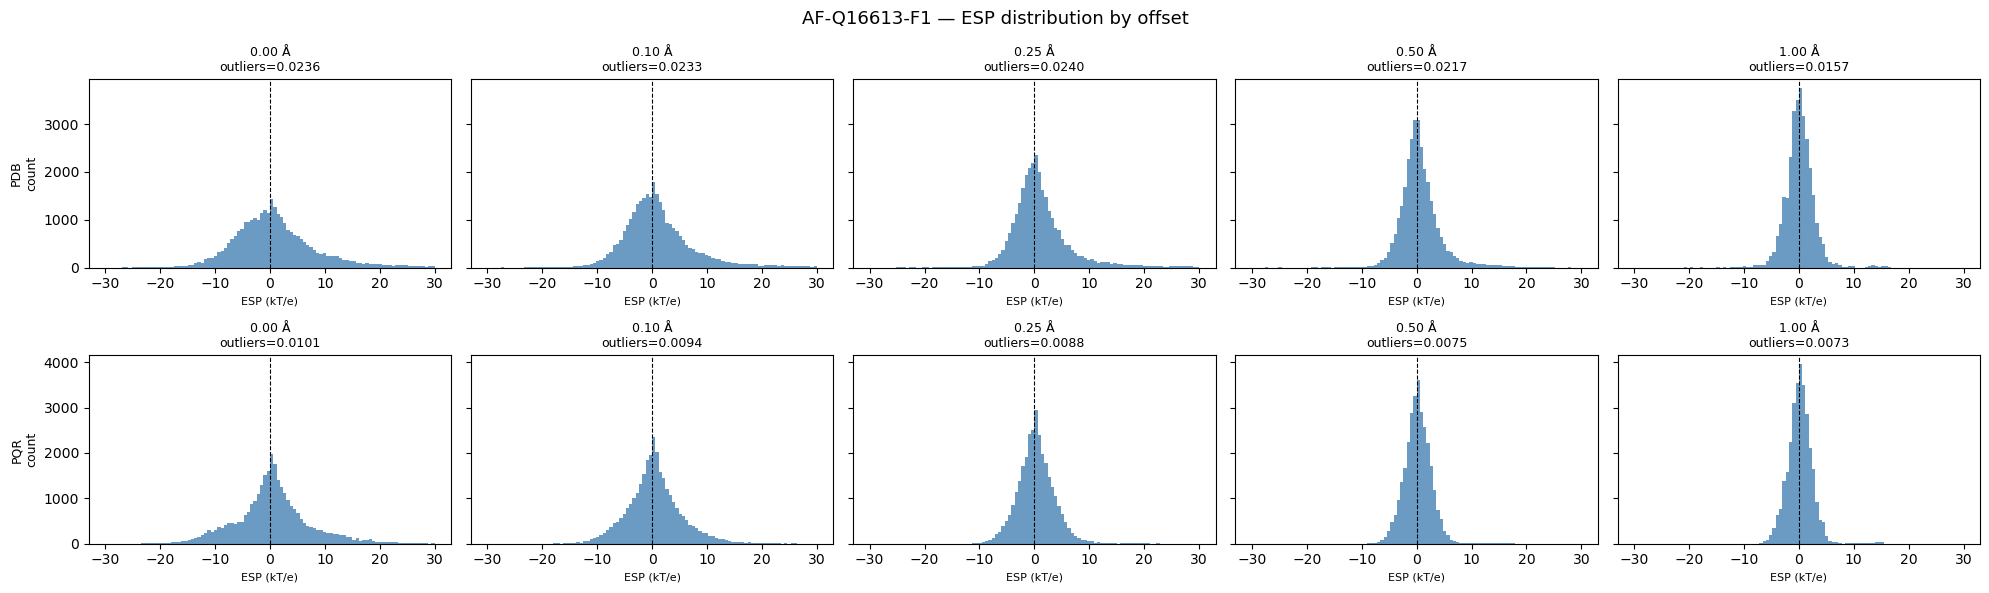

In [66]:
# ── Distribution plot per protein ─────────────────────────────────────────────
BINS       = 100
HIST_RANGE = (-30, 30)   # kT/e — adjust to your data
OUT_DIR    = Path("../../outputs")
OUT_DIR.mkdir(exist_ok=True)

for pid in PROTEIN_IDS:
    fig, axes_grid = plt.subplots(
        2, len(OFFSETS),
        figsize=(4 * len(OFFSETS), 6),
        sharey="row", sharex="row"
    )
    fig.suptitle(f"{pid} — ESP distribution by offset", fontsize=13)

    for row_idx, variant in enumerate(["pdb", "pqr"]):
        for col_idx, offset in enumerate(OFFSETS):
            ax  = axes_grid[row_idx, col_idx]
            esp = sweep[pid][variant][offset]
            out = outlier_fraction(esp)

            ax.hist(esp, bins=BINS, range=HIST_RANGE, color="steelblue", alpha=0.8)
            ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
            ax.set_title(f"{offset:.2f} Å\noutliers={out:.4f}", fontsize=9)
            ax.set_xlabel("ESP (kT/e)", fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(f"{variant.upper()}\ncount", fontsize=9)

    plt.tight_layout()
    out_path = OUT_DIR / f"{pid}_offset_distributions.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()

---
## Visualisation

Grid layout per protein: **3 rows × N columns**

| | col per offset value |
|---|---|
| **Row 0: PDB** (no H) | ESP at each offset |
| **Row 1: PQR** (with H) | ESP at each offset |
| **Row 2: \|PQR − PDB\|** | Difference projected onto PDB mesh |

All panels share the same colour scale. Rotate to a meaningful view then press `s` to save.

In [67]:
# ── Visualisation settings ────────────────────────────────────────────────────
CLIM            = (-5, 5)   # ESP colour range kT/e — adjust to your data
DIFF_CLIM       = (0, 3)      # difference heatmap range
COLORMAP        = "RdBu_r"
DIFF_CMAP       = "hot_r"
PROTEIN_TO_PLOT = PROTEIN_IDS[0]

Renders a static 3×N grid (PDB row / PQR row / |PQR−PDB| row, one column per offset) to an inline image. Adjust `CLIM` and `CAMERA` here before running. Use the interactive cell below to rotate freely.

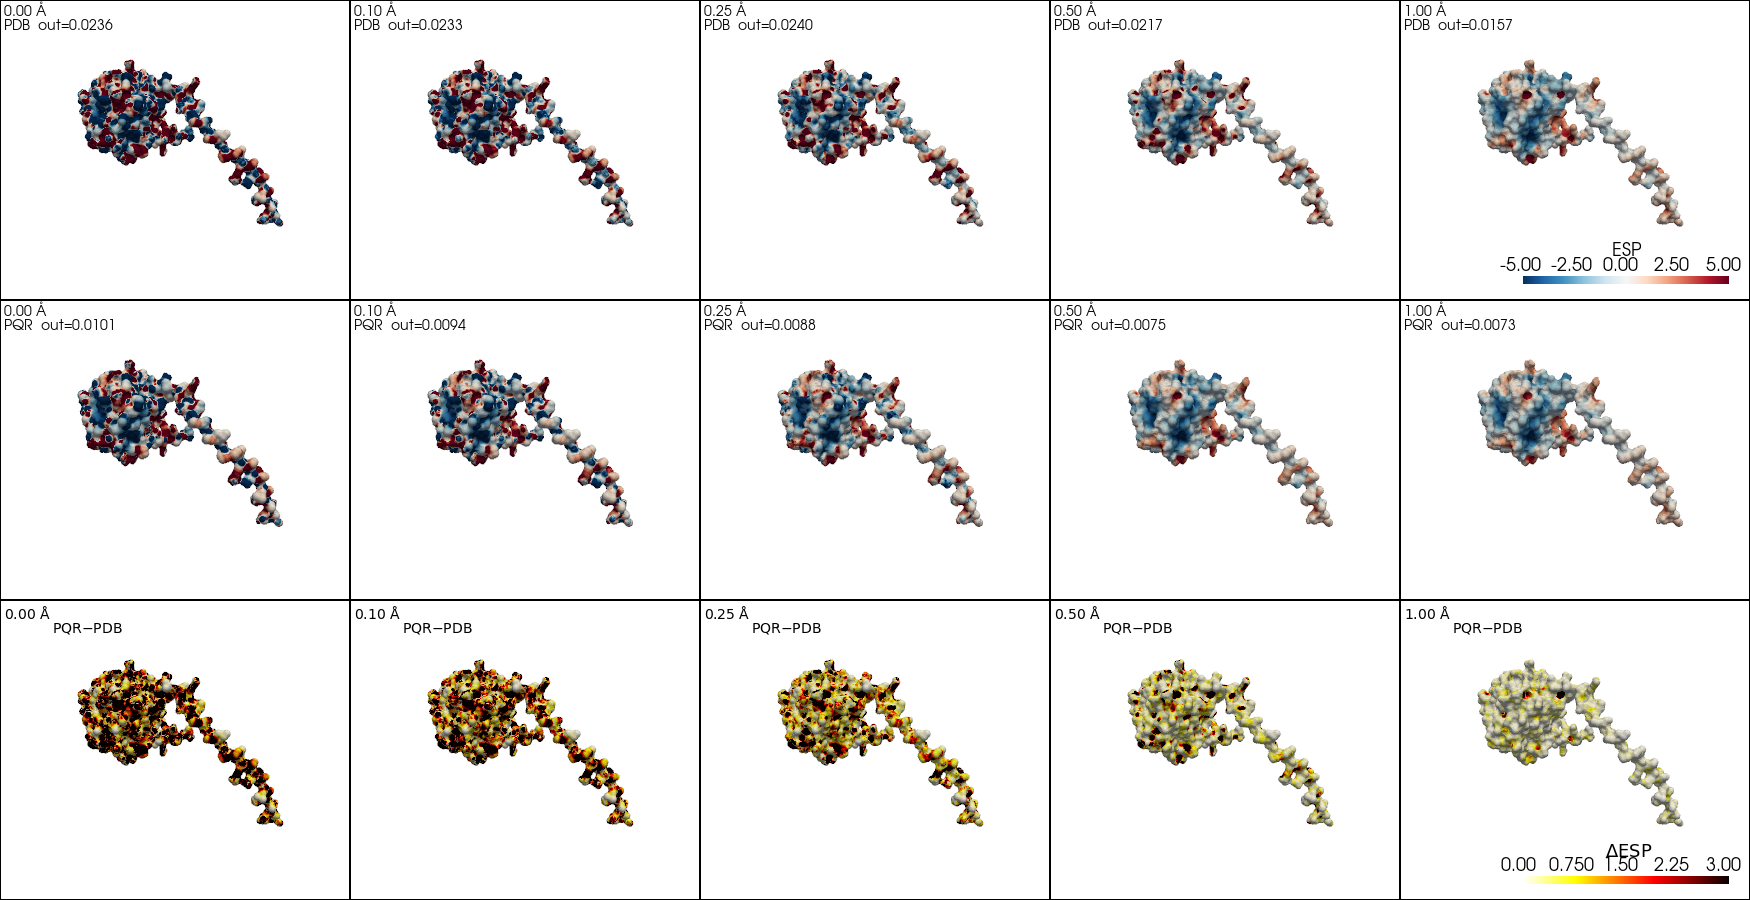

In [68]:
def make_pv_mesh(verts, faces, esp_verts, scalar_name="ESP"):
    n_faces = len(faces)
    pad     = np.full((n_faces, 1), 3, dtype=int)
    cells   = np.hstack([pad, faces]).ravel()
    surf    = pv.PolyData(verts, cells)
    surf[scalar_name] = esp_verts
    return surf


pid    = PROTEIN_TO_PLOT
n_cols = len(OFFSETS)

verts_pdb = meshes[pid]["pdb"]["verts"]
faces_pdb = meshes[pid]["pdb"]["faces"]
verts_pqr = meshes[pid]["pqr"]["verts"]
faces_pqr = meshes[pid]["pqr"]["faces"]

tree = cKDTree(verts_pqr)
_, nn_idx = tree.query(verts_pdb)

# Camera position — adjust until the view looks right, then run the terminal cell to save
# Common options: "iso", "xy", "xz", "yz"  or set a tuple ((x,y,z), (fx,fy,fz), (ux,uy,uz))
CAMERA = "iso"

pl = pv.Plotter(shape=(3, n_cols), window_size=(350 * n_cols, 900), off_screen=True)
pl.set_background("white")

for col_idx, offset in enumerate(OFFSETS):
    esp_pdb = sweep[pid]["pdb"][offset]
    esp_pqr = sweep[pid]["pqr"][offset]
    esp_pqr_on_pdb = esp_pqr[nn_idx]
    diff = np.abs(esp_pqr_on_pdb - esp_pdb)
    out_pdb = outlier_fraction(esp_pdb)
    out_pqr = outlier_fraction(esp_pqr)
    label   = f"{offset:.2f} Å"

    pl.subplot(0, col_idx)
    pl.add_mesh(make_pv_mesh(verts_pdb, faces_pdb, esp_pdb),
                scalars="ESP", cmap=COLORMAP, clim=CLIM,
                show_scalar_bar=(col_idx == n_cols - 1))
    pl.add_text(f"{label}\nPDB  out={out_pdb:.4f}", font_size=8)
    pl.camera_position = CAMERA

    pl.subplot(1, col_idx)
    pl.add_mesh(make_pv_mesh(verts_pqr, faces_pqr, esp_pqr),
                scalars="ESP", cmap=COLORMAP, clim=CLIM,
                show_scalar_bar=False)
    pl.add_text(f"{label}\nPQR  out={out_pqr:.4f}", font_size=8)
    pl.camera_position = CAMERA

    pl.subplot(2, col_idx)
    pl.add_mesh(make_pv_mesh(verts_pdb, faces_pdb, diff, scalar_name="|ΔESP|"),
                scalars="|ΔESP|", cmap=DIFF_CMAP, clim=DIFF_CLIM,
                show_scalar_bar=(col_idx == n_cols - 1))
    pl.add_text(f"{label}\n|PQR−PDB|", font_size=8)
    pl.camera_position = CAMERA

import PIL.Image, io
img = pl.screenshot(return_img=True)
pl.close()
pil_img = PIL.Image.fromarray(img)
buf = io.BytesIO()
pil_img.save(buf, format="PNG")
ipy_display(ipy_Image(data=buf.getvalue(), format="png"))

---
## Notes & Observations

**0.0 Å (exact surface):**
- PDB mesh: massive spikes (std=13.3, max=130.5 kT/e). Near-surface heavy atoms without explicit hydrogens place sampling points extremely close to charge singularities in the DX grid.
- PQR mesh: much better (std=6.9, max=40.9) since hydrogen atoms are present, pushing the surface boundary outward slightly. However, discontinuities still occur at ~1% of vertices.

**Small offsets (0.1–0.25 Å):**
- Meaningful spike reduction: PQR std falls from 6.9 → 5.0 → 3.4 kT/e. High correlation with surface values preserved (r=0.98–0.91).
- Not sufficient to fully eliminate outliers; edge gradients remain high.

**0.5 Å offset — chosen value:**
- PQR range [−10.3, 17.8] kT/e. Std=2.6. Outlier fraction drops to 0.76%. Mean edge gradient halves compared to the surface (1.82 vs. 3.57), indicating a smooth, physically coherent field.
- This offset places sample points in the solvent-accessible region just outside the SES, where the ESP is most relevant to protein–ligand and protein–protein interactions.
- Pearson r vs. surface is 0.77 — surface character is preserved while singularities are suppressed.

**1.0 Å offset:**
- Only marginal further smoothing (std=2.3 vs. 2.6). The field loses meaningful structure: Pearson r vs. surface drops to 0.67. Over-smoothing outweighs the small gain in spike suppression.

**PDB vs. PQR:**
- PDB mesh is unsuitable at all offsets: at 0.5 Å it still has std=4.2 and range [−38.1, 39.4] — roughly double the dynamic range of the PQR mesh. This is the primary reason the pipeline adopts PQR-only meshes.

**Decision:** 0.5 Å offset, PQR mesh only.

In [70]:
# ── Interactive window (terminal) ─────────────────────────────────────────────
# Writes the current sweep data to a temp script and launches it in a terminal
# so you can rotate freely and press s to save.
# Run this cell after the visualisation cell above looks roughly correct.

import pickle, subprocess, textwrap, tempfile

_data = {
    "sweep":     sweep,
    "meshes":    meshes,
    "pid":       PROTEIN_TO_PLOT,
    "OFFSETS":   OFFSETS,
    "CLIM":      CLIM,
    "DIFF_CLIM": DIFF_CLIM,
    "COLORMAP":  COLORMAP,
    "DIFF_CMAP": DIFF_CMAP,
    "CAMERA":    CAMERA,
}
_pkl = tempfile.NamedTemporaryFile(suffix=".pkl", delete=False)
pickle.dump(_data, open(_pkl.name, "wb"))

_script = textwrap.dedent(f"""
    import pickle, numpy as np, pyvista as pv
    from scipy.spatial import cKDTree

    d = pickle.load(open({repr(_pkl.name)}, "rb"))
    sweep, meshes, pid = d["sweep"], d["meshes"], d["pid"]
    OFFSETS, CLIM, DIFF_CLIM = d["OFFSETS"], d["CLIM"], d["DIFF_CLIM"]
    COLORMAP, DIFF_CMAP, CAMERA = d["COLORMAP"], d["DIFF_CMAP"], d["CAMERA"]

    def make_pv_mesh(verts, faces, esp, name="ESP"):
        pad   = np.full((len(faces), 1), 3, dtype=int)
        cells = np.hstack([pad, faces]).ravel()
        s = pv.PolyData(verts, cells); s[name] = esp; return s

    def outlier_fraction(esp, sigma=3.0):
        if len(esp) == 0: return 0.0
        return float(np.mean(np.abs(esp) > np.mean(esp) + sigma * np.std(esp)))

    verts_pdb, faces_pdb = meshes[pid]["pdb"]["verts"], meshes[pid]["pdb"]["faces"]
    verts_pqr, faces_pqr = meshes[pid]["pqr"]["verts"], meshes[pid]["pqr"]["faces"]
    _, nn_idx = cKDTree(verts_pqr).query(verts_pdb)
    n_cols = len(OFFSETS)

    pl = pv.Plotter(shape=(3, n_cols), window_size=(350 * n_cols, 900))
    pl.set_background("white")

    for ci, offset in enumerate(OFFSETS):
        ep = sweep[pid]["pdb"][offset]
        eq = sweep[pid]["pqr"][offset]
        
        # Calculate derived data for labels
        out_pdb = outlier_fraction(ep)
        out_pqr = outlier_fraction(eq)
        diff = np.abs(eq[nn_idx] - ep)
        
        # Define the three rows
        rows = [
            (verts_pdb, faces_pdb, ep,   "ESP",   CLIM,      COLORMAP, f"{{offset:.2f}} Å\\nPDB out={{out_pdb:.4f}}"),
            (verts_pqr, faces_pqr, eq,   "ESP",   CLIM,      COLORMAP, f"{{offset:.2f}} Å\\nPQR out={{out_pqr:.4f}}"),
            (verts_pdb, faces_pdb, diff, "|ΔESP|", DIFF_CLIM, DIFF_CMAP, f"{{offset:.2f}} Å\\n|PQR−PDB|"),
        ]

        for ri, (v, f, e, name, clim, cmap, txt) in enumerate(rows):
            pl.subplot(ri, ci)
            
            # Logic: Show scalar bar only on the last column for row 0 (ESP) and row 2 (Diff)
            show_bar = (ci == n_cols - 1) and (ri == 0 or ri == 2)
            
            pl.add_mesh(make_pv_mesh(v, f, e, name), 
                        scalars=name,
                        cmap=cmap, 
                        clim=clim, 
                        show_scalar_bar=show_bar)
            
            pl.add_text(txt, font_size=8, color="black")
            pl.camera_position = CAMERA
            
    pl.link_views() # Keeps all subplots rotating together
    pl.show(title=f"{{pid}} — Offset Sweep Visualization")
""")

_script_file = tempfile.NamedTemporaryFile(suffix=".py", delete=False, mode="w")
_script_file.write(_script); _script_file.close()

subprocess.Popen(
    ["bash", "-c", f"DISPLAY=:0 conda run -n protein_esp python {_script_file.name}"]
)
print("Launched interactive window in terminal.")

Launched interactive window in terminal.
